In [1]:
import numpy as np
import pandas as pd
import matlab.engine
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

eng = matlab.engine.start_matlab()

In [14]:
def shell_radii(fractions, R):
    """
    Computes cumulative radii of a multilayer system.
    Model: r_i = R * (x_i)^(1/3)
    where x_i is the cumulative sum of fractions.
    """
    x = np.cumsum(fractions) #cumulative sum
    r = R * np.cbrt(x) #cube root
    return r

def mono_exp(x, TB):
    return 1 - np.exp(-x / TB)  # beta = 1

def fit_mono(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values 
    popt, _ = curve_fit(mono_exp, t, y, bounds=([0], [np.inf]))
    TB = popt[0]
    yfit = mono_exp(t, *popt)
    return pd.Series({"TB": TB, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def stretched_exp(x, TB, beta):
    return 1 - np.exp(-(x / TB) ** beta)

def fit_stretched(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values
    popt, _ = curve_fit(stretched_exp, t, y,bounds=([0, 0], [np.inf, np.inf]))
    TB, beta = popt
    yfit = stretched_exp(t, *popt)
    return pd.Series({"TB": TB, "beta" : beta, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def r2(y, yfit):
    ss_res = np.sum((y - yfit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot 

R = 0.05 #radius of LNP in um
compounds =  ["mRNA 1", "mRNA 2", "Lipid 1", "Lipid 2"]
distrib =  np.array([0.05, 0.05, 0.95, 0.95]) # fictious

## defining models

In [56]:
rows = []
rows_name = []
n = 3

for i in range (n+1):
    x = i / n
    a = x
    b = (1 - x)
    rows.append((i+1, b, a, a, b))
    rows_name.append((f'{i+1}', f'{round(b*100)}/{round(a*100)}'))

percentage = pd.DataFrame(rows, columns=["model","mRNA 1","mRNA 2","Lipid 1", "Lipid 2"]).set_index(["model"])
models_name =  pd.DataFrame(rows_name, columns=["model", "name"]).set_index(["model"])

rows = []
for i in range (n+1):
    if (i == 0 or i == n):
        rows.append((i+1, 1, 1, 0, 1, 0))
        rows.append((i+1, 2, 0, 1, 0, 1))
    else:
        rows.append((i+1, 1, 1, 0, 0, 0))
        rows.append((i+1, 2, 0, 0, 1, 0))
        rows.append((i+1, 3, 0, 1, 0, 0))
        rows.append((i+1, 4, 0, 0, 0, 1))

models = pd.DataFrame(rows, columns=["model", "shell", "mRNA 1","mRNA 2","Lipid 1", "Lipid 2"]).set_index(["model", "shell"])
models = models[models.columns].mul(percentage[models.columns], level="model")
id_models = models.index.get_level_values("model").unique()

In [57]:
models_distrib = models.mul(distrib) #relative volume contributions
# print("total volume :", models_distrib.groupby("model").sum().sum(axis=1))

## start processing data : getting raddi

In [58]:
models_data = pd.DataFrame(0, index=models.index, columns=[])

# store the contribution of each shell
models_data["%"] = models_distrib.sum(axis = 1)
#print("total shell :", models_data["%"].groupby("model").sum())

radii = models_data["%"].groupby("model").transform(lambda s: shell_radii(s, R))

models_data["r_max"] = radii #um
models_data["r_min"] = radii.groupby("model").shift(fill_value=0) #um
models_data["thickness"] = np.round((models_data["r_max"] - models_data["r_min"])*1e3, 3) #nm

radiis = radii.groupby("model").apply(lambda s: np.pad(s, (1,0)))
radiis = radiis.to_frame("radii")

# models_data

## storage for plots : 
* nb of point for a compound in a shell : N = x * A * k
* x : ratio of this compound in the shell
* A : area of the shell
* k : multiplication factor (r_max and r_min are in um not nm, area is reaaaally small)


In [59]:
models_shells = models.div(models.sum(axis=1), axis=0) #relative contribution per shell
# print("nb of shell :", models_shells.groupby("model").sum().sum(axis=1))

In [60]:
area = np.pi * (models_data["r_max"]**2 - models_data["r_min"]**2)  
nb_points = models_shells.loc[models_shells.index, compounds]
k = 1.5e6
nb_points = np.round(nb_points.mul(area, axis=0) * k ).fillna(0).astype(int)    
total_points = nb_points.groupby("model").sum().sum(axis =1)
print(total_points)

rows = []
for model, shell in models.index:
    r_min = models_data.loc[(model, shell), "r_min"]
    r_max = models_data.loc[(model, shell), "r_max"]
    for c in compounds:
        n_points = nb_points.loc[(model, shell), c]
        
        #uniform distribution on the area of the shell
        phi = np.random.uniform(0, 2*np.pi, n_points)
        r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_points))
        
        # convert from polar to cartesian 
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        for k in range(n_points):
            rows.append((model, shell, c, x[k], y[k]))

#store for drawing later
models_points = pd.DataFrame(rows, columns=["model","shell","compound", "x", "y"])
models_points = models_points.set_index(["model", "shell", "compound"])

model
1    11781
2    11781
3    11781
4    11781
dtype: int64


## spin diffusion simulation

In [61]:
m = 2                 # m=0 for 1D, m=1 for 2D, m=2 for 3D

rstep = 1000          # number of points in space domain
tmax = 100            # maximum time in s
tstep =200           # number of points in time domain

epsilon0 = 154        # source enhancement
T1source = 2.3        # source build up time in s
T1target = 4.5        # intrinsic relaxation time of the target in s

slope = 60000         # slope of the tanh function
theta = 0.9           # percentage of quenched signal in the source
dep = 0.5             # percentage of depolarization in the source
Cp = 2.54e-2          # Molar heat capacity of 1H spins at 9.4 T Prisco_2021

length_target = R     # length of the target in um
length_source = 0.09  # length of the source in um

concX = 117           # 1H concentration in the target in molar
concjuice = 12        # 1H concentration in the source in molar
Din = 1.5e-4          # LNP diffusion coefficient based on Viger-Gravel_2018
MAS = 12              # MAS rate in kHz
D0 = 4.25e-3          # fictive diffusion coefficient of PS in a static sample: Pinon_thesis
#The source diffusion coeff is scaled with the proton concentration and MAS
Dout = D0*(concjuice/70)**(1/3)/(1+0.6*MAS)

In [62]:
rows = []

for id_model in radiis.index:
    r = radiis.loc[id_model]

    signals = eng.spin_diffusion(
    float(m), float(length_target), float(rstep), float(tmax), float(tstep), 
    float(T1source), float(T1target), float(epsilon0), float(Din), float(Dout),
    float(length_source), float(slope), float(theta), float(dep), float(concjuice), 
    float(concX), float(Cp), matlab.double(r.tolist()))
    
    for i, (s_off, s_on, t) in enumerate( zip(signals["S_off"], signals["S_on"], signals["t"])):
        #m.double (matlab) to np.array
        s_off = np.array(s_off)[0] 
        s_on = np.array(s_on)[0]
        t = np.array(t)[0]    
        for ti, off, on in zip(t, s_off, s_on):
            rows.append({"model" : id_model, "shell": i+1, "t": ti, "S_off": off, "S_on": on})
    print(f"model {id_model} processed")

models_signals = pd.DataFrame(rows)
models_signals = models_signals.set_index(["model", "shell"])

model 1 processed
model 2 processed
model 3 processed
model 4 processed


## observables computation

In [63]:
double_shell_id = models_signals.index.get_level_values("model")[models_signals.index.get_level_values("shell") > 3].unique()
double_shell = models_signals.loc[double_shell_id]

compound_rows = []
for name, signal in double_shell.groupby("model"):
    signal = signal.droplevel("model")
    S_on_mRNA = signal.loc[1, 'S_on'].values + signal.loc[3, 'S_on'].values
    S_off_mRNA = signal.loc[1, 'S_off'].values + signal.loc[3, 'S_off'].values
    S_on_lipid = signal.loc[2, 'S_on'].values + signal.loc[4, 'S_on'].values #Ionizible Lipid
    S_off_lipid = signal.loc[2, 'S_off'].values + signal.loc[4, 'S_off'].values #Ionizible Lipid
    for i, (s_on_mRNA, s_off_mRNA, s_on_lipid, s_off_lipid, t) in enumerate(zip(S_on_mRNA, S_off_mRNA, S_on_lipid, S_off_lipid, signal["t"])):
        compound_rows.append({"model" : name, "shell" : 13, "t": t, "S_on": s_on_mRNA, "S_off": s_off_mRNA,})
        compound_rows.append({"model" : name, "shell" : 24, "t": t, "S_on": s_on_lipid,"S_off": s_off_lipid})

compound_signals =  pd.DataFrame(compound_rows)
compound_signals = compound_signals.set_index(["model", "shell"])
models_signals = pd.concat([models_signals, compound_signals]).sort_index()
models_data = models_data.reindex(models_signals.index.unique()).fillna(0) #ajout des nouvelles lignes

In [64]:
models_signals["epsilon"]= models_signals["S_on"] / models_signals["S_off"] 
models_signals.loc[models_signals["epsilon"].isna(), "epsilon"] = 0

#recycle time d1 used in experiment -> taking enhancement at that time 
d1 = 5.5 # in s 
models_signals["dist"] = np.abs(models_signals["t"] - d1) 
dist_min = models_signals.sort_values("dist").groupby(["model", "shell"]).head(1) #minimal distance from d1
models_data["epsilon_d1"] = dist_min.sort_index(level=["model", "shell"])["epsilon"]


In [65]:
# normalized S_on for TB fit
S_on_max = models_signals.sort_values("S_on").groupby(["model", "shell"]).tail(1)
models_signals["normS_on"] = models_signals["S_on"]  / S_on_max.sort_index(level=["model", "shell"])["S_on"]

# fitting for having TB 
# mono exponential
fit_m = models_signals.groupby(["model", "shell"]).apply(fit_mono, "normS_on")
models_data["TB_m"] = fit_m["TB"]
models_data["R2_m"] = fit_m["R2"]
models_signals["fit_m"] = fit_m["yfit"].explode()
models_signals["residuals_m"] = fit_m["residuals"].explode()

# # stretched exponential
fit_s = models_signals.groupby(["model", "shell"]).apply(fit_stretched, "normS_on")
models_data["TB_s"] = fit_s["TB"]
models_data["R2_s"] = fit_s["R2"]
models_data["beta"] = fit_s["beta"]
models_signals["fit_s"] = fit_s["yfit"].explode()
models_signals["residuals_s"] = fit_s["residuals"].explode()
models_data


%     r_max     r_min  thickness  epsilon_d1      TB_m  \
model shell                                                                  
1     1      0.050000  0.018420  0.000000     18.420   13.918270  6.295605   
      2      0.950000  0.050000  0.018420     31.580   24.113399  4.970511   
2     1      0.033333  0.016091  0.000000     16.091   13.607011  6.347437   
      2      0.316667  0.035236  0.016091     19.145   18.019035  5.687620   
      3      0.016667  0.035787  0.035236      0.551   21.402525  5.275694   
      4      0.633333  0.050000  0.035787     14.213   27.084278  4.694470   
      13     0.000000  0.000000  0.000000      0.000   16.206706  5.929837   
      24     0.000000  0.000000  0.000000      0.000   23.984477  4.982573   
3     1      0.016667  0.012772  0.000000     12.772   13.258874  6.406486   
      2      0.633333  0.043312  0.012772     30.540   20.708303  5.346715   
      3      0.033333  0.044040  0.043312      0.728   26.910177  4.714722   
      4      0.316667  0.050000  0.044040      5.960   29.871897  4.457018   
      13     0.000000  0.000000  0.000000      0.000   22.066302  5.171334   
      24     0.000000  0.000000  0.000000      0.000   23.663098  5.014542   
4     1      0.950000  0.049152  0.000000     49.152   23.151262  5.068288   
      2      0.050000  0.050000  0.049152      0.848   32.143680  4.277854   

                 R2_m      TB_s      R2_s      beta  
model shell                                          
1     1      0.966788  6.657430  0.998879  1.633291  
      2      0.990471  5.180554  0.999860  1.274263  
2     1      0.965765  6.713252  0.998833  1.648184  
      2      0.978292  5.991968  0.999358  1.465180  
      3      0.985035  5.530305  0.999572  1.362153  
      4      0.993702  4.863445  0.999917  1.213988  
      13     0.974627  6.261265  0.999327  1.520750  
      24     0.990354  5.194228  0.999862  1.276372  
3     1      0.964595  6.776676  0.998781  1.665242  
      2      0.984461  5.610103  0.999632  1.372265  
      3      0.993245  4.888178  0.999880  1.222519  
      4      0.996268  4.586966  0.999976  1.158833  
      13     0.988361  5.408400  0.999868  1.311049  
      24     0.989955  5.230793  0.999855  1.283369  
4     1      0.989161  5.292524  0.999830  1.296883  
      2      0.997889  4.375682  0.999999  1.116001

## results : from shell to component

In [66]:
models_compound = models_shells.divide(models_shells.groupby("model").sum()) #relative contribution per compound
# print("number of compound :", models_compound.groupby("model").sum().sum(axis=1))

In [73]:
result = ["epsilon_d1", "TB_m", "TB_s"]
final = ['mRNA 1', 'mRNA 2', "mRNA", 'Lipid 1', 'Lipid 2', "Lipid"]

models_result = pd.DataFrame(0.0, 
                            index = pd.MultiIndex.from_product([id_models, final], 
                            names=["model", "compound"]), 
                            columns=result)


# using models_compound to have the contribution of each compound 
epsilon_values = models_compound.mul(models_data["epsilon_d1"], axis=0).groupby("model").sum()
epsilon_values = epsilon_values.stack()
models_result["epsilon_d1"] = epsilon_values

TB_m_values = models_compound.mul(models_data["TB_m"], axis=0).groupby("model").sum()
TB_m_values = TB_m_values.stack()
models_result["TB_m"] = TB_m_values

TB_s_values = models_compound.mul(models_data["TB_s"], axis=0).groupby("model").sum()
TB_s_values = TB_s_values.stack()
models_result["TB_s"] = TB_s_values

models_result.loc[(double_shell_id, "mRNA"), "epsilon_d1"] = models_data.loc[(double_shell_id, 13), "epsilon_d1"].values
models_result.loc[(double_shell_id, "Lipid"), "epsilon_d1"] = models_data.loc[(double_shell_id, 24), "epsilon_d1"].values

models_result.loc[(double_shell_id, "mRNA"), "TB_m"] = models_data.loc[(double_shell_id, 13), "TB_m"].values
models_result.loc[(double_shell_id, "Lipid"), "TB_m"] = models_data.loc[(double_shell_id, 24), "TB_m"].values

models_result.loc[(double_shell_id, "mRNA"), "TB_s"] = models_data.loc[(double_shell_id, 13), "TB_s"].values
models_result.loc[(double_shell_id, "Lipid"), "TB_s"] = models_data.loc[(double_shell_id, 24), "TB_s"].values

models_result = models_result.replace(np.nan, 0)
# models_result

## visualization

In [110]:
compound = models_result.index.get_level_values("compound")
mask = ~compound.str.contains("Lipid")
models_result = models_result[mask]
print(models_result)

                epsilon_d1      TB_m      TB_s
model compound                                
1     mRNA 1     13.918270  6.295605  6.657430
      mRNA 2      0.000000  0.000000  0.000000
      mRNA        0.000000  0.000000  0.000000
2     mRNA 1     13.607011  6.347437  6.713252
      mRNA 2     21.402525  5.275694  5.530305
      mRNA       16.206706  5.929837  6.261265
3     mRNA 1     13.258874  6.406486  6.776676
      mRNA 2     26.910177  4.714722  4.888178
      mRNA       22.066302  5.171334  5.408400
4     mRNA 1      0.000000  0.000000  0.000000
      mRNA 2     32.143680  4.277854  4.375682
      mRNA        0.000000  0.000000  0.000000


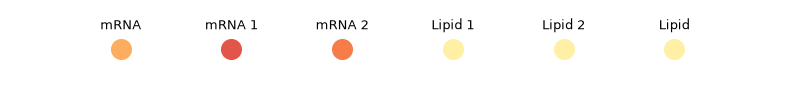

In [100]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.15, 0.45, 5))
# cmap = plt.get_cmap("viridis")(np.linspace(0.4, 0.9, 2))

compound_colors = {
        "mRNA": cmap[2],
        "mRNA 1": cmap[0],
        "mRNA 2": cmap[1],

        "Lipid 1": cmap[-1],
        "Lipid 2": cmap[-1],
        "Lipid":cmap[-1]
    } 
fig, ax = plt.subplots(figsize=(10, 1))
for i, (c, color) in enumerate(compound_colors.items()):
    ax.scatter(i, 0, color=color, s=200)
    ax.text(i, 0.5, str(c), ha='center', fontsize=9)
ax.set_xlim(-1, len(compound_colors))
ax.set_ylim(-1, 1)
ax.axis("off")

plt.show()

In [101]:
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 25,
    "axes.titlesize": 20,
    "xtick.labelsize": 15,
    "legend.fontsize": 25,
    "figure.titlesize": 20,
})

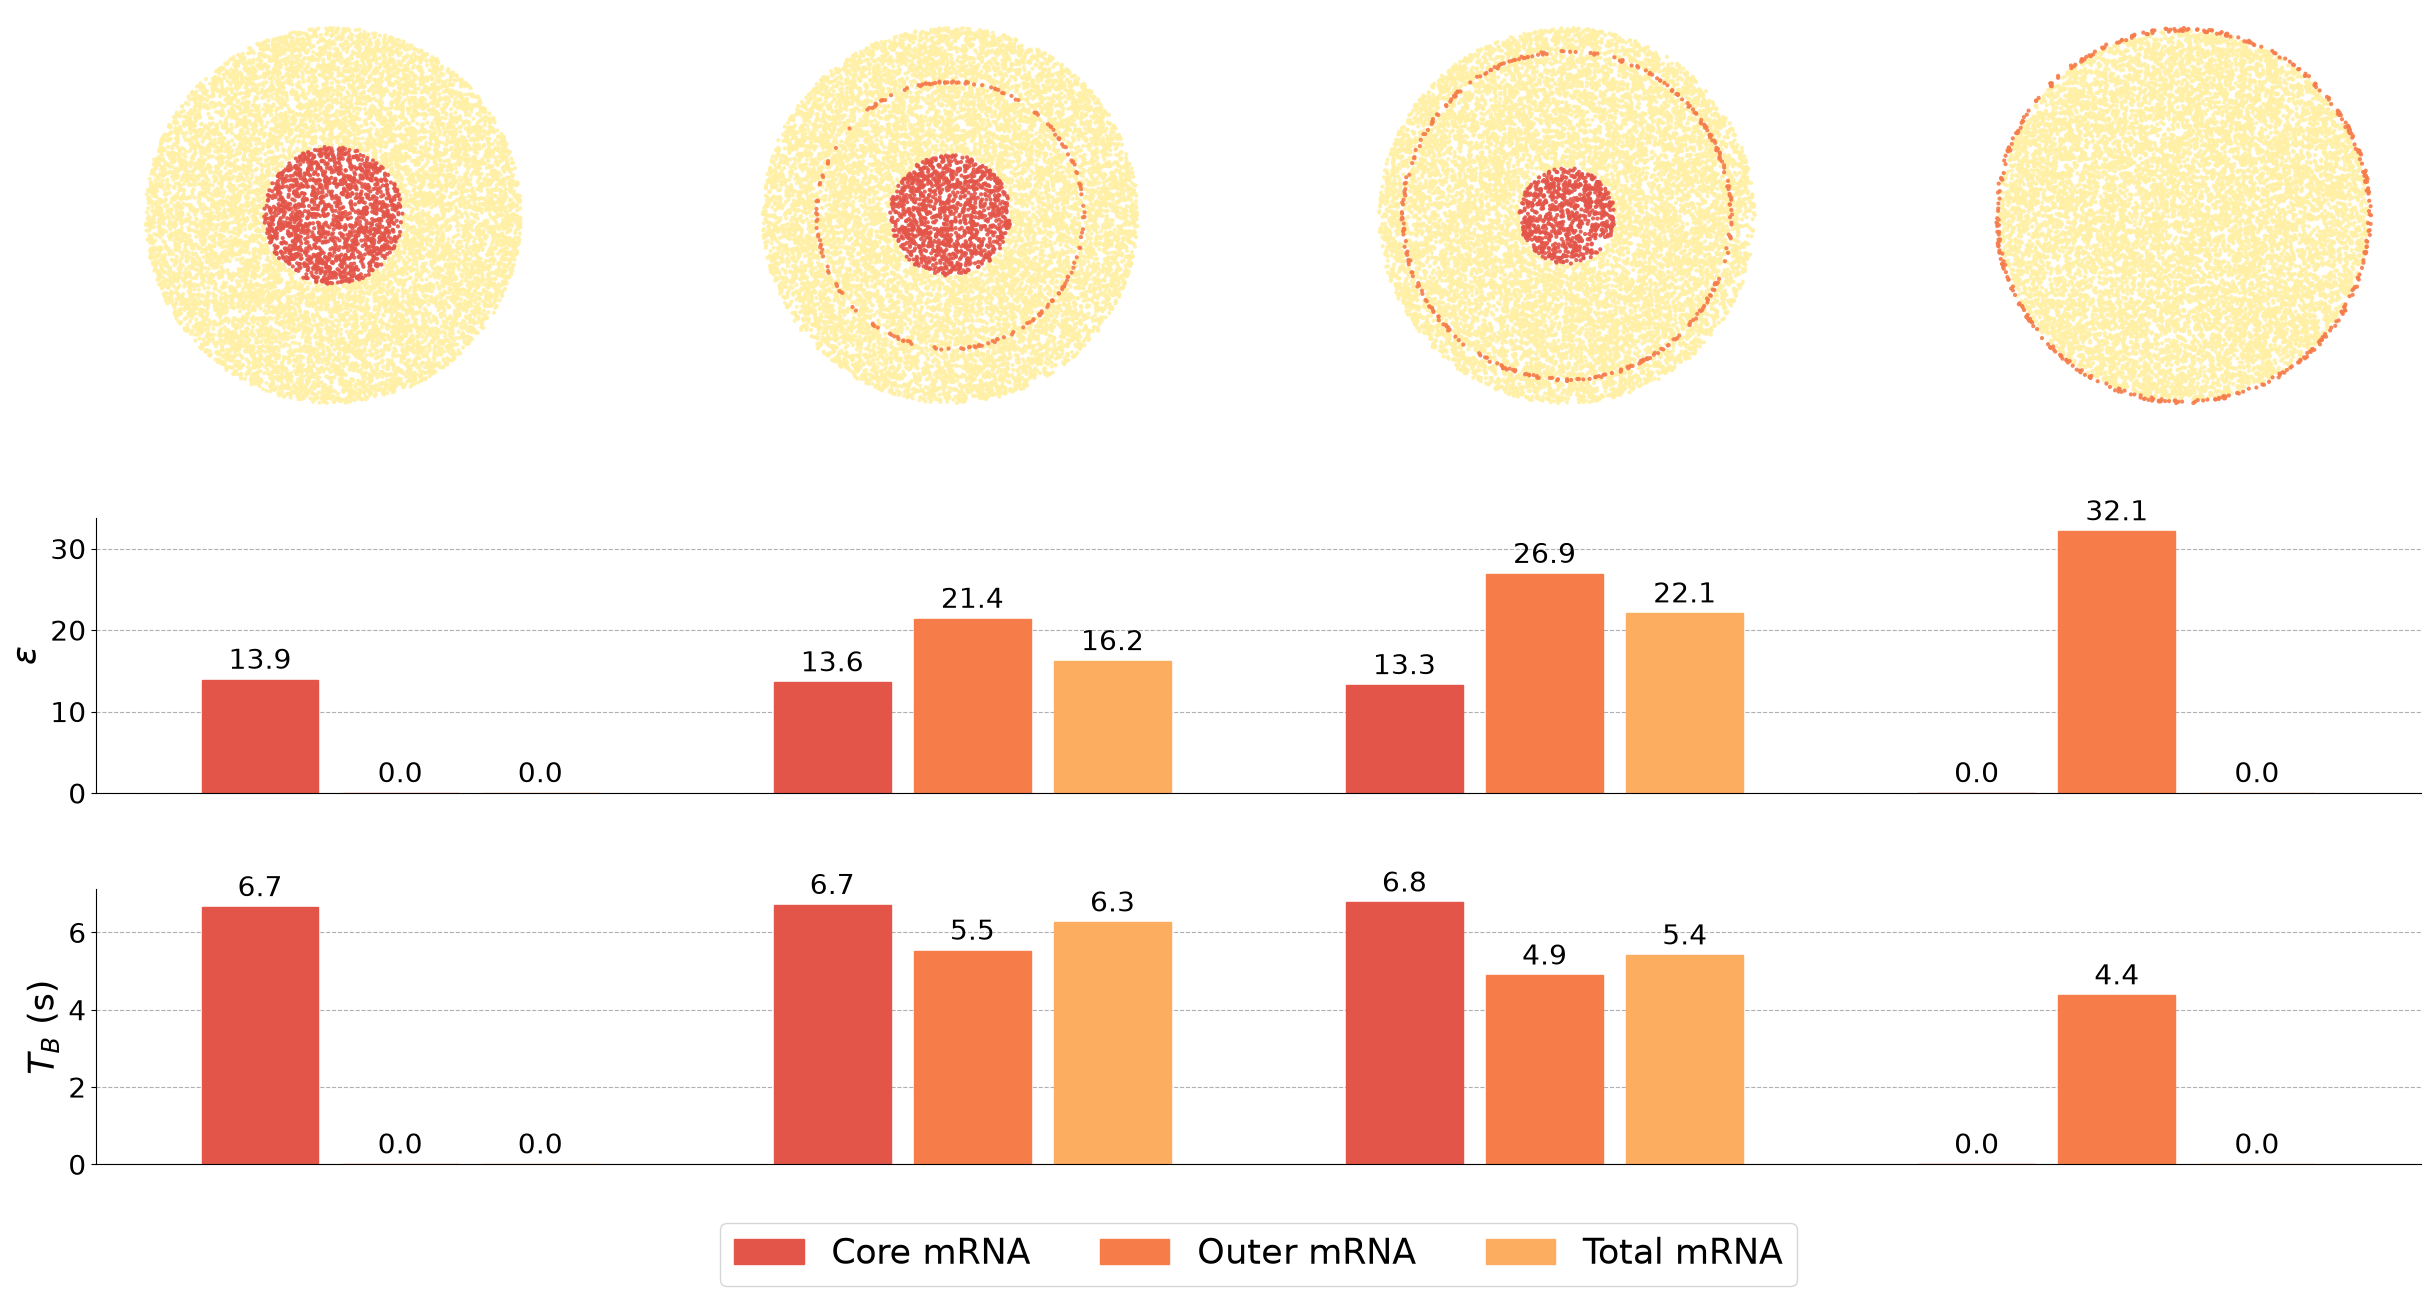

In [109]:
N = len(id_models)
fig = plt.figure(figsize=(30, 15))
# gs = fig.add_gridspec(4, N, height_ratios=[0.2, 1.3, 1, 1])
gs = fig.add_gridspec(3, N, height_ratios=[1.5, 1, 1])

axes = {}
for n in range(N):
    base = n
    # axes[f"title_{n}"] = fig.add_subplot(gs[0, base])
    axes[f"lnp_{n}"] = fig.add_subplot(gs[0, base])
axes[f"epsilon"] = fig.add_subplot(gs[1, :])
axes[f"TB"] = fig.add_subplot(gs[2, :])

for n, (name, model_points) in enumerate(models_points.groupby("model")):
    # ax_title = axes[f"title_{n}"]
    ax = axes[f"lnp_{n}"]

    # ax_title.axis("off")
    # ax_title.text(0.5, -0.5, f"model {models_name.loc[name, "name"]}",  ha="center", fontsize=30)
    
    for c, compound_points in model_points.groupby("compound"):
        ax.scatter(compound_points["x"], compound_points["y"],s=9, alpha=0.9, edgecolors='none', color = compound_colors[c])
        ax.set_aspect("equal")
        ax.axis('off')

epsilon = models_result["epsilon_d1"].unstack().reindex(columns=["mRNA 1", "mRNA 2", "mRNA"])
ax1 = axes["epsilon"]
ax1.set_ylabel(r"$\varepsilon$")
ax1.grouped_bar(epsilon, bar_spacing=0.2)
ax1.set_xticks([])
for container, compound in zip(ax1.containers, epsilon.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])  
    labels = [f"{v:.1f}" for v in epsilon[compound]]
    ax1.bar_label(container, labels=labels, padding=3)


TB = models_result["TB_s"].unstack().reindex(columns=final).reindex(columns=["mRNA 1", "mRNA 2", "mRNA"])
ax2 = axes["TB"]
ax2.set_ylabel(r"$T_B$ (s)")
ax2.grouped_bar(TB, bar_spacing=0.2)
ax2.set_xticks([])
for container, compound in zip(ax2.containers, TB.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])
    labels = [f"{v:.1f}" for v in TB[compound]]
    ax2.bar_label(container, labels=labels, padding=3)

for ax in (ax1, ax2):
    ax.grid(True, axis="y", linestyle="--")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = ax2.get_legend_handles_labels()
mapping = {"mRNA 1": "Core mRNA", "mRNA 2": "Outer mRNA",  "mRNA": "Total mRNA",}
labels = [mapping.get(label, label) for label in labels]
ax2.legend(handles, labels, ncol=len(labels), loc="upper center", bbox_to_anchor=(0.5, -0.15))

fig.subplots_adjust(hspace=0.3, wspace = 0.3)
plt.savefig("mRNA_distrib.png", dpi=150, bbox_inches="tight")
plt.show()